YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed
/var/folders/b4/3kqm5xr9151fzlbt93c3dg740000gn/T/ipykernel_54498/4224604898.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Signal'][data['MA_50'] > data['MA_200']] = 1  # 短期均线上穿长期均线，产生买入信号
/var/folders/b4/3kqm5xr9151fzlbt93c3dg740000gn/T/ipykernel_54498/4224604898.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Signal'][data['MA_50'] < data['MA_200']] = -1  # 短期均线下穿长期均线，产生卖出信号


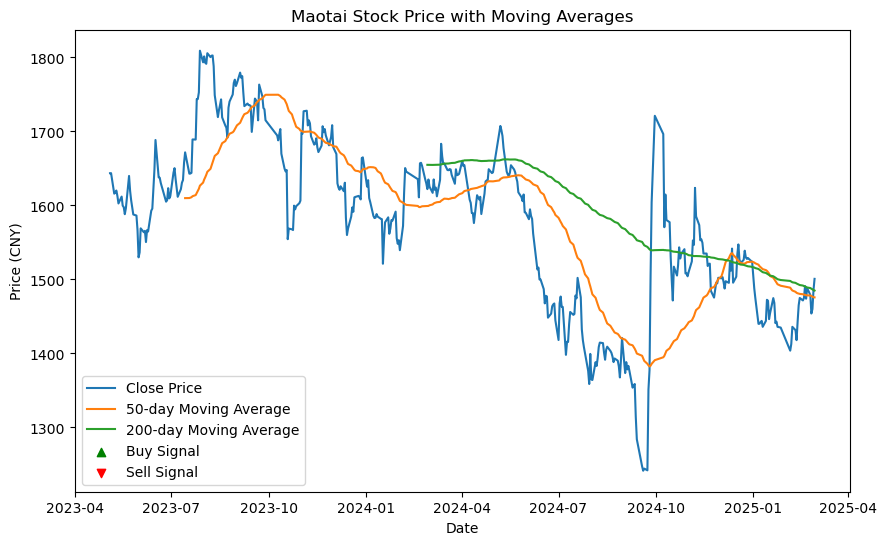

In [3]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# 获取贵州茅台股票数据
symbol = "600519.SS"
start_date = "2023-05-01"
end_date = "2025-03-01"

data = yf.download(symbol, start=start_date, end=end_date)

# 计算短期（50天）和长期（200天）移动平均
data['MA_50'] = data['Close'].rolling(window=50).mean()
data['MA_200'] = data['Close'].rolling(window=200).mean()

# 生成买卖信号
data['Signal'] = 0
data['Signal'][data['MA_50'] > data['MA_200']] = 1  # 短期均线上穿长期均线，产生买入信号
data['Signal'][data['MA_50'] < data['MA_200']] = -1  # 短期均线下穿长期均线，产生卖出信号

# 绘制股价和移动平均线
plt.figure(figsize=(10, 6))
plt.plot(data['Close'], label='Close Price')
plt.plot(data['MA_50'], label='50-day Moving Average')
plt.plot(data['MA_200'], label='200-day Moving Average')

# 标记买卖信号
plt.scatter(data[data['Signal'] == 1].index, data[data['Signal'] == 1]['MA_50'], marker='^', color='g', label='Buy Signal')
plt.scatter(data[data['Signal'] == -1].index, data[data['Signal'] == -1]['MA_50'], marker='v', color='r', label='Sell Signal')

plt.title("Maotai Stock Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (CNY)")
plt.legend()
plt.show()

[*********************100%***********************]  1 of 1 completed


Price         Close         High          Low         Open        Volume
Ticker    600519.SS    600519.SS    600519.SS    600519.SS     600519.SS
count    541.000000   541.000000   541.000000   541.000000  5.410000e+02
mean    1591.520002  1607.010527  1577.653417  1592.465001  2.867965e+06
std      111.729991   111.681734   111.564076   113.418545  1.640746e+06
min     1241.583496  1254.284807  1226.647036  1242.075715  0.000000e+00
25%     1511.955200  1528.380005  1498.791129  1516.287474  1.925701e+06
50%     1610.918091  1624.966096  1598.518592  1610.728099  2.544925e+06
75%     1669.786133  1683.985659  1654.043958  1670.743881  3.255892e+06
max     1809.014526  1880.590353  1795.625648  1880.590353  1.947095e+07


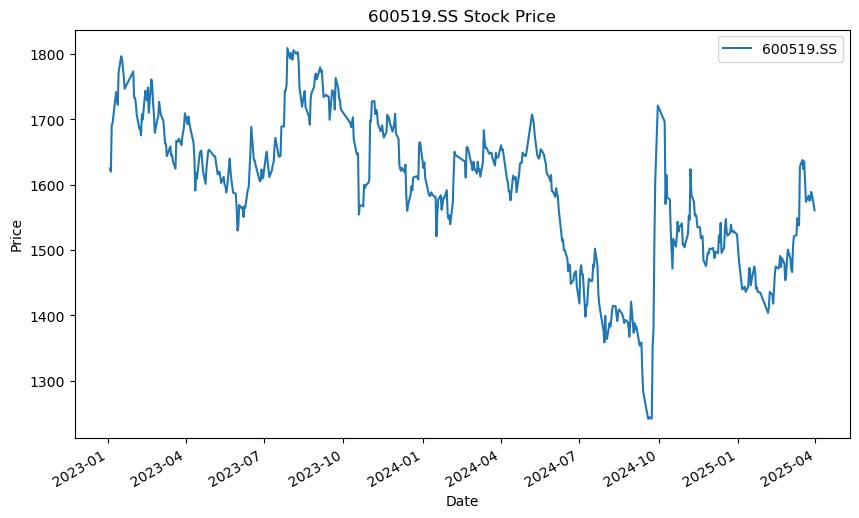

In [8]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 获取股票数据
#symbol = "TSLA"
#symbol = "1810.HK"
symbol = "600519.SS"  # 茅台
start_date = "2023-01-01"
end_date = "2025-04-01"

data = yf.download(symbol, start=start_date, end=end_date)
# 简单的数据分析
print(data.describe())

# 绘制股价走势图
data['Close'].plot(figsize=(10, 6), label=symbol)
plt.title(f"{symbol} Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

In [10]:
import yfinance as yf

# 获取股票数据
symbol = "600519.SS"
start_date = "2022-01-01"
end_date = "2023-01-01"

data = yf.download(symbol, start=start_date, end=end_date)
print(data.head())


[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open    Volume
Ticker        600519.SS    600519.SS    600519.SS    600519.SS 600519.SS
Date                                                                    
2022-01-04  1881.974243  1898.232063  1847.816267  1885.433182   3384262
2022-01-05  1856.990967  1894.607879  1851.486053  1876.258166   2839551
2022-01-06  1818.658325  1868.000729  1778.555064  1855.165114   5179475
2022-01-07  1781.757202  1824.768936  1779.298291  1812.034230   2981669
2022-01-10  1803.776733  1813.869075  1759.324600  1768.921464   2962670
